<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/titanic/titanic_acuracy_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first 5 rows
print("First 5 rows of the Titanic dataset:")
print(titanic_df.head())

# Display a summary of the DataFrame
print("\nInformation about the Titanic dataset:")
titanic_df.info()

First 5 rows of the Titanic dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Information about the Titanic dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dty

In [ ]:
#titanic_df

In [35]:
# Family size
titanic_df["FamilySize"] = titanic_df["sibsp"] + titanic_df["parch"] + 1

# Is Alone
titanic_df["alone"] = 0
titanic_df.loc[titanic_df["FamilySize"] == 1, "alone"] = 1

# Fill missing Age by median grouped by Sex and Pclass
titanic_df["age"] = titanic_df.groupby(["sex","pclass"])["age"].transform(lambda x: x.fillna(x.median()))

# Fill Fare
titanic_df["fare"] = titanic_df["fare"].fillna(titanic_df["fare"].median())


In [36]:
# 1. Calculate the mean of 'age' and fill missing values
# age_mean = titanic_df['age'].mean()
# titanic_df['age'] = titanic_df['age'].fillna(age_mean)

# 2. Find the mode of 'embarked' and fill missing values
embarked_mode = titanic_df['embarked'].mode()[0]
titanic_df['embarked'] = titanic_df['embarked'].fillna(embarked_mode)

# 3. Find the mode of 'embark_town' and fill missing values
embark_town_mode = titanic_df['embark_town'].mode()[0]
titanic_df['embark_town'] = titanic_df['embark_town'].fillna(embark_town_mode)

# 4. Drop the 'deck' column if it exists
if 'deck' in titanic_df.columns:
    titanic_df.drop(columns=["deck"], axis=1, inplace=True)

# 5. Verify that all missing values have been handled
print("\nMissing values after handling:")
print(titanic_df.isnull().sum())


Missing values after handling:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
FamilySize     0
dtype: int64


In [ ]:
# y = titanic_df['survived']
# X = titanic_df[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone', 'FamilySize']]

# # Identify categorical columns and apply one-hot encoding
# categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns
# X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# # Split the data into training and testing sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print("Shape of X_train:", X_train.shape)
# print("Shape of X_test:", X_test.shape)
# print("Shape of y_train:", y_train.shape)
# print("Shape of y_test:", y_test.shape)
# print("\nFirst 5 rows of preprocessed X:")
# print(X.head())

In [37]:
le = LabelEncoder()

for col in ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'FamilySize']:
    titanic_df[col] = le.fit_transform(titanic_df[col])

X = titanic_df.drop("survived", axis=1)
y = titanic_df["survived"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of preprocessed X:")
print(X.head())

Shape of X_train: (712, 14)
Shape of X_test: (179, 14)
Shape of y_train: (712,)
Shape of y_test: (179,)

First 5 rows of preprocessed X:
   pclass  sex  age  sibsp  parch  fare  embarked  class  who  adult_male  \
0       2    1   29      1      0    18         2      2    1           1   
1       0    0   52      1      0   207         0      0    2           0   
2       2    0   35      0      0    41         2      2    2           0   
3       0    0   48      1      0   189         2      0    2           0   
4       2    1   48      0      0    43         2      2    1           1   

   embark_town  alive  alone  FamilySize  
0            2      0      0           1  
1            0      1      0           1  
2            2      1      1           0  
3            2      1      0           1  
4            2      0      1           0  


In [38]:
# Instantiate the Decision Tree Classifier
# dtc = DecisionTreeClassifier()
dtc = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=7,
    random_state=42,
    criterion='gini'
    )

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


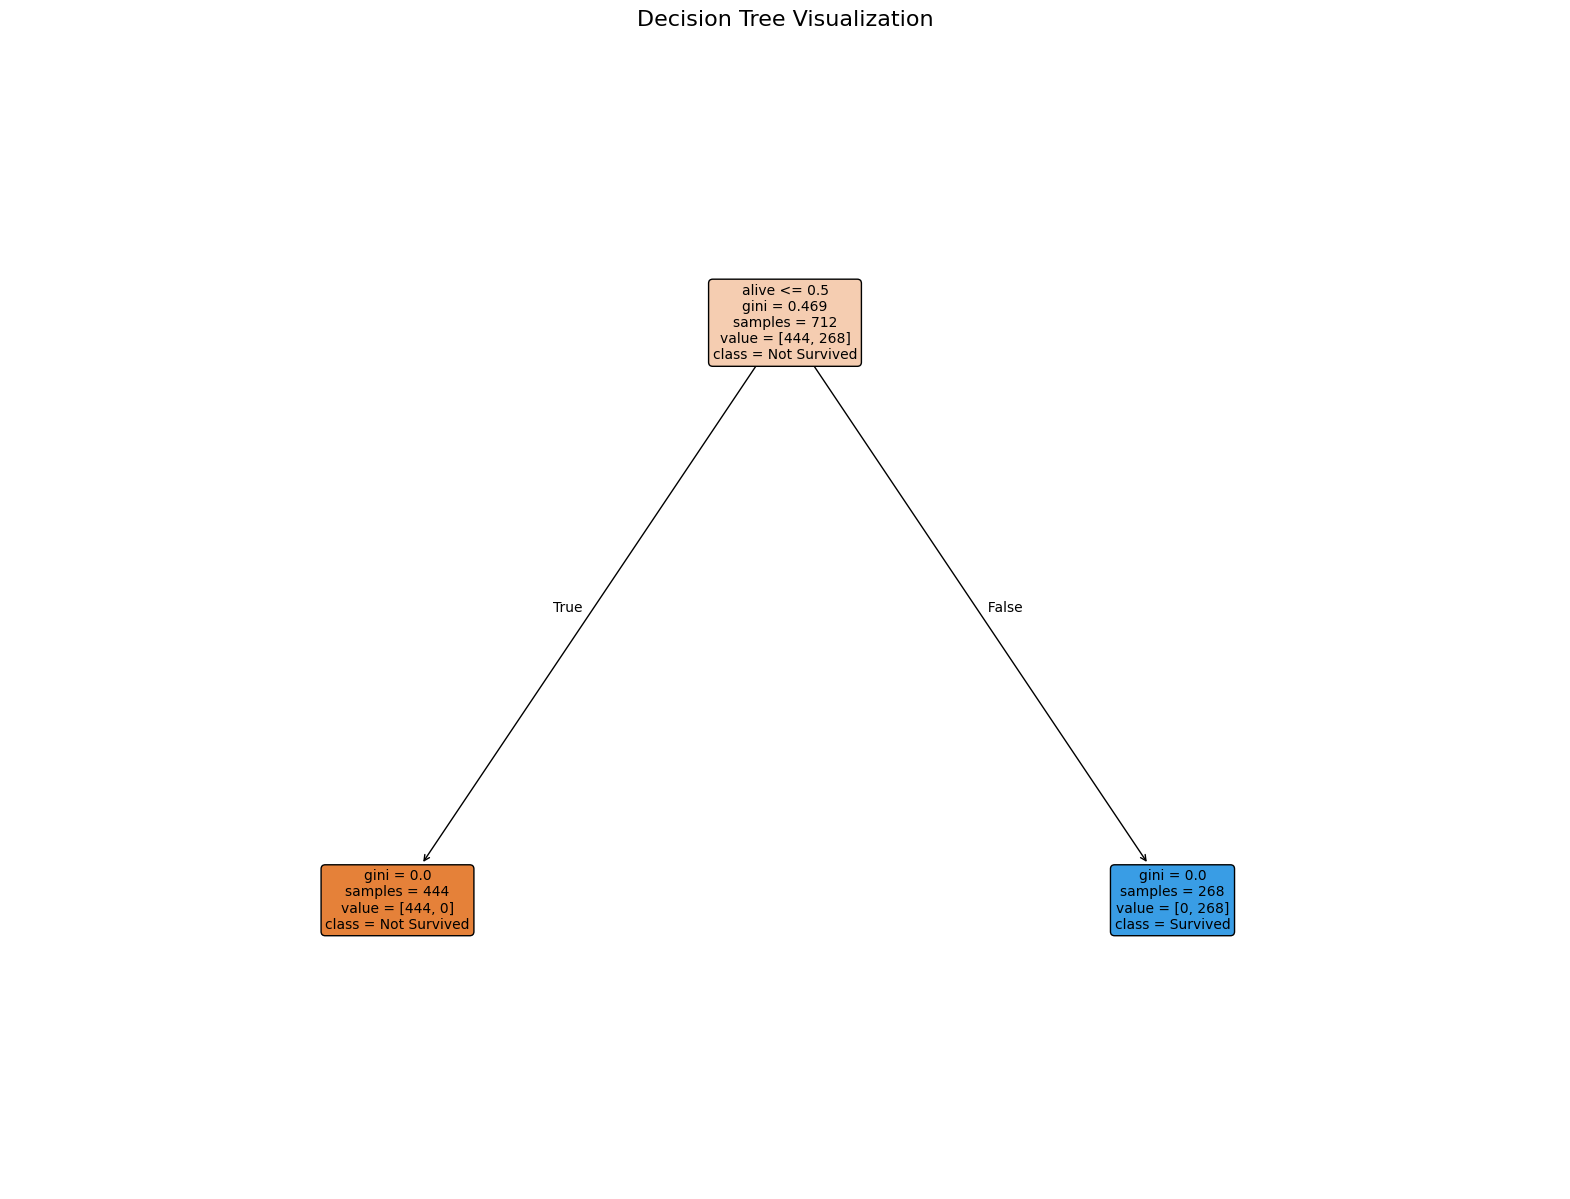

Decision Tree visualized successfully.


In [42]:
# Create a figure and an axes object for the plot
plt.figure(figsize=(20, 15))

# Visualize the decision tree
plot_tree(dtc,
          feature_names=X_train.columns,
          class_names=["Not Survived", "Survived"],
          filled=True,
          rounded=True,
          fontsize=10)

# Add a title to the plot
plt.title('Decision Tree Visualization', fontsize=16)

# Display the plot
plt.show()

print("Decision Tree visualized successfully.")

In [43]:
# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 1.0000
